In [6]:
import requests
import time
import random
import sqlite3
import re
import os

# --- Настройки ---
TARGET_BRANDS = [
    'skoda', 'volkswagen', 'bmw', 'audi', 'mercedes-benz', 
    'ford', 'hyundai', 'kia', 'toyota', 'renault', 
    'peugeot', 'seat', 'opel', 'citroen', 'fiat', 
    'mazda', 'honda', 'nissan', 'volvo', 'subaru'
]

os.makedirs("data", exist_ok=True)
DB_NAME = "data/cars.db"

# --- 1. Функция парсинга мощности ---
def parse_power(text):
    if not text: return None
    match = re.search(r'(\d+)\s*[kK][wW]', str(text))
    if match:
        return int(match.group(1))
    return None


# --- 2. Функция инициализации БД ---
def init_db():
    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS cars (
            id INTEGER PRIMARY KEY,
            brand TEXT,
            model_name TEXT,
            details TEXT,  
            price INTEGER,
            year INTEGER,
            mileage INTEGER,
            fuel TEXT,
            gearbox TEXT,
            power INTEGER,
            url TEXT,
            parsed_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
        )
    ''')
    conn.commit()
    return conn

conn = init_db()
cursor = conn.cursor()

url = "https://www.sauto.cz/api/v1/items/search"
headers = {
    'accept': 'application/json',
    'user-agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
}

print(f"🚀 СТАРТ: Начинаем сбор данных в {DB_NAME}...")

total_saved = 0

for brand in TARGET_BRANDS:
    print(f"\n🚘 --- Марка: {brand.upper()} ---")
    page = 0
    max_pages = 50 
    
    while page < max_pages:
        params = {
            'limit': 20,
            'offset': page * 20,
            'category_id': 838,
            'condition_seo': 'nove,ojete,predvadeci',
            'manufacturer_model_seo': brand,
        }
        
        try:
            # Используем двойной таймаут из успешного теста!
            response = requests.get(url, headers=headers, params=params, timeout=(5, 15))
            
            if response.status_code == 200:
                data = response.json()
                results = data.get("results", [])
                
                if not results:
                    print(f"   🪹 {brand.upper()}: Машины закончились на странице {page + 1}.")
                    break
                
                for car in results:
                    car_id = car.get("id")
                    name = car.get("name")
                    details = car.get("additional_model_name") 
                    price = car.get("price")
                    
                    date_str = car.get("manufacturing_date") or car.get("in_operation_date") or ""
                    year = int(date_str[:4]) if date_str and date_str[:4].isdigit() else None
                    
                    mileage = car.get("tachometer")
                    fuel = car.get("fuel_cb", {}).get("name")
                    gearbox = car.get("gearbox_cb", {}).get("name")
                    
                    power = car.get("power")
                    if not power: power = parse_power(details)
                    if not power: power = parse_power(name)
                    
                    seo_url = car.get("seo", {}).get("url")
                    full_url = seo_url if seo_url else f"https://www.sauto.cz/osobni/detail/{brand}/car/{car_id}"

                    cursor.execute('''
                        INSERT OR IGNORE INTO cars 
                        (id, brand, model_name, details, price, year, mileage, fuel, gearbox, power, url)
                        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
                    ''', (car_id, brand, name, details, price, year, mileage, fuel, gearbox, power, full_url))
                
                conn.commit()
                total_saved += len(results)
                print(f"\r   ✅ {brand}: стр. {page + 1} сохранена. Всего в базе: {total_saved}", end="", flush=True)
                page += 1
                
            else:
                print(f"   🚨 Ошибка сайта! Код: {response.status_code}")
                break
                
        except Exception as e:
            print(f"   💥 Ошибка на {brand} (стр. {page + 1}): {e}")
            continue
            
        time.sleep(random.uniform(1.5, 3.5))

conn.close()
print(f"\n\n🏁 ГОТОВО! Сбор данных завершен. Всего машин в БД: {total_saved}")

🚀 СТАРТ: Начинаем сбор данных в data/cars.db...

🚘 --- Марка: SKODA ---
   ✅ skoda: стр. 50 сохранена. Всего в базе: 1000
🚘 --- Марка: VOLKSWAGEN ---
   ✅ volkswagen: стр. 50 сохранена. Всего в базе: 2000
🚘 --- Марка: BMW ---
   ✅ bmw: стр. 49 сохранена. Всего в базе: 2980   💥 Ошибка на bmw (стр. 50): HTTPSConnectionPool(host='www.sauto.cz', port=443): Read timed out. (read timeout=5)
   ✅ bmw: стр. 50 сохранена. Всего в базе: 3000
🚘 --- Марка: AUDI ---
   ✅ audi: стр. 50 сохранена. Всего в базе: 4000
🚘 --- Марка: MERCEDES-BENZ ---
   ✅ mercedes-benz: стр. 50 сохранена. Всего в базе: 5000
🚘 --- Марка: FORD ---
   ✅ ford: стр. 50 сохранена. Всего в базе: 6000
🚘 --- Марка: HYUNDAI ---
   ✅ hyundai: стр. 50 сохранена. Всего в базе: 7000
🚘 --- Марка: KIA ---
   ✅ kia: стр. 50 сохранена. Всего в базе: 8000
🚘 --- Марка: TOYOTA ---
   ✅ toyota: стр. 50 сохранена. Всего в базе: 9000
🚘 --- Марка: RENAULT ---
   ✅ renault: стр. 50 сохранена. Всего в базе: 10000
🚘 --- Марка: PEUGEOT ---
   ✅ peug

In [7]:
import pandas as pd
import sqlite3
import numpy as np

# 1. Connection
conn = sqlite3.connect("data/cars.db")
df = pd.read_sql("SELECT * FROM cars", conn)
conn.close()

print(f"📥 Raw data records: {len(df)}")

# --- FILTERING ---
# Removing price outliers (junk below 30k and exclusives above 5M)
df = df[(df['price'] > 30000) & (df['price'] < 5000000)]

# Removing duplicates (in case IDs were repeated)
df = df.drop_duplicates(subset=['id'])

# --- DROPPING UNNECESSARY COLUMNS ---
# id, url, parsed_at - these don't affect the price physics
cols_to_drop = ['id', 'url', 'parsed_at', 'model_name']  # model_name is too noisy and often duplicates details
df = df.drop(columns=cols_to_drop, errors='ignore')

# --- MISSING DATA HANDLING (Imputation) ---
# For text: replace NaN with "Unknown"
text_cols = ['brand', 'details', 'fuel', 'gearbox']
for col in text_cols:
    df[col] = df[col].fillna("Unknown")

# For numbers: FIXING POWER (power) 🛠️
# 1. Convert to numeric, turn all errors (like text) into NaN
df['power'] = pd.to_numeric(df['power'], errors='coerce')

# 2. Remove anomalies: everything less than 20 kW or more than 600 kW becomes NaN
df.loc[(df['power'] < 20) | (df['power'] > 600), 'power'] = np.nan

# 3. Smart filling: use median by brand and specific trim (details)
df['power'] = df['power'].fillna(df.groupby(['brand', 'details'])['power'].transform('median'))

# 4. If the trim is rare and still empty, use the median by brand only
df['power'] = df['power'].fillna(df.groupby('brand')['power'].transform('median'))

# 5. If any "orphans" remain, fill with the overall database median
df['power'] = df['power'].fillna(df['power'].median())

# --- SAVING ---
output_file = "data/cars_ready.csv"
df.to_csv(output_file, index=False)

print(f"🧹 After cleaning: {len(df)}")
print(f"💾 Data saved to '{output_file}'")
print(df.head(3))

📥 Raw data records: 19055
🧹 After cleaning: 18816
💾 Data saved to 'data/cars_ready.csv'
     brand                        details  price  year  mileage   fuel  \
0  renault      Serviska cebia VIN MAILEM  99000  2010   239000  Nafta   
1   subaru  2,0 Active Combi, nová spojka  72000  2009   189704  Nafta   
2   nissan            1.9 dCi First Class  40000  2003   207000  Nafta   

    gearbox  power  
0  Manuální   85.0  
1  Manuální  110.0  
2  Manuální   87.0  


📂 Data loaded: 18816 rows


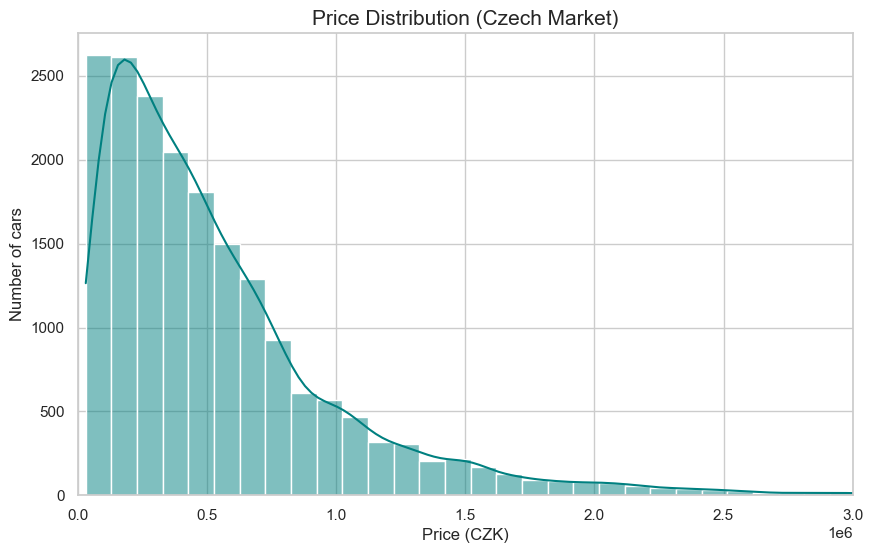

/var/folders/nf/_plpz1p57pv31n9md8s7b1s40000gn/T/ipykernel_22649/3650378053.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='brand', y='price', data=df_top, palette='viridis', order=top_brands)


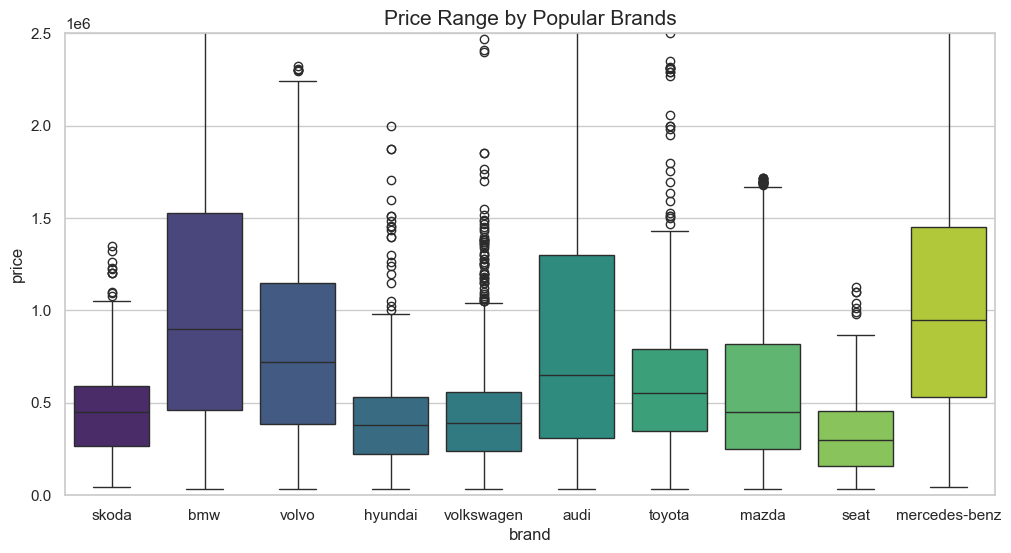

/var/folders/nf/_plpz1p57pv31n9md8s7b1s40000gn/T/ipykernel_22649/3650378053.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='body_type_guess', y='price', data=df_body, palette='coolwarm')


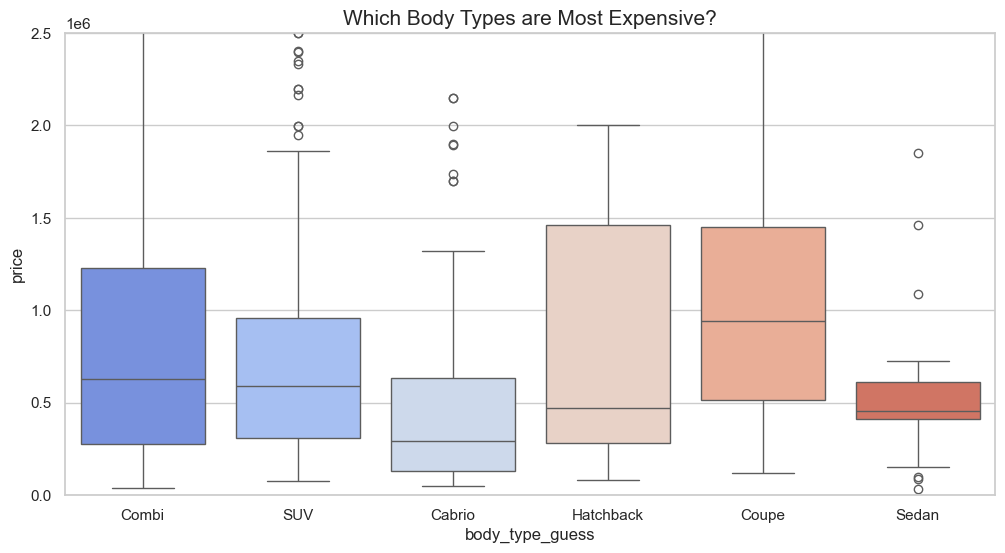

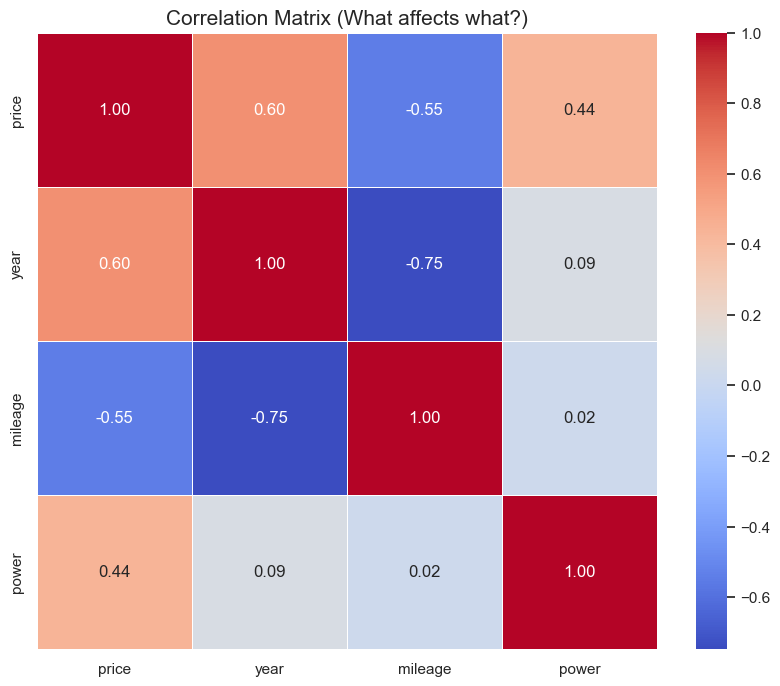

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Plot style settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Load data
df = pd.read_csv("data/cars_ready.csv")
print(f"📂 Data loaded: {len(df)} rows")

# --- HACK: Extract Body Type from text for the chart ---
def guess_body_type(text):
    t = str(text).lower()
    if any(x in t for x in ['combi', 'kombi', 'avant', 'variant', 'touring', 'sw']): return 'Combi'
    if any(x in t for x in ['suv', 'cross', 'tiguan', 'kodiaq', 'touareg', 'x5', 'q7', 'cr-v']): return 'SUV'
    if any(x in t for x in ['sedan', 'limuzina', 'limousin']): return 'Sedan'
    if any(x in t for x in ['hatchback', 'fabia', 'golf', 'polo']): return 'Hatchback'
    if any(x in t for x in ['coupe', 'coupé']): return 'Coupe'
    if any(x in t for x in ['cabrio', 'kabrio']): return 'Cabrio'
    return 'Other'

df['body_type_guess'] = df['details'].apply(guess_body_type)

# --- PLOT 1: Histogram (How are prices distributed?) ---
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True, color='teal')
plt.title('Price Distribution (Czech Market)', fontsize=15)
plt.xlabel('Price (CZK)')
plt.ylabel('Number of cars')
plt.xlim(0, 3000000) # Cut the tail > 3M for better visualization
plt.show()

# --- PLOT 2: Boxplot (Price vs Brand) ---
# Taking only Top-10 brands to avoid clutter
top_brands = df['brand'].value_counts().head(10).index
df_top = df[df['brand'].isin(top_brands)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='brand', y='price', data=df_top, palette='viridis', order=top_brands)
plt.title('Price Range by Popular Brands', fontsize=15)
plt.ylim(0, 2500000)
plt.show()

# --- PLOT 3: Boxplot (Price vs Body Type) ---
plt.figure(figsize=(12, 6))
# Remove "Other" category to keep it clean
df_body = df[df['body_type_guess'] != 'Other']
sns.boxplot(x='body_type_guess', y='price', data=df_body, palette='coolwarm')
plt.title('Which Body Types are Most Expensive?', fontsize=15)
plt.ylim(0, 2500000)
plt.show()

# --- PLOT 4: Heatmap (What correlates with what?) ---
# Calculating correlation for numeric values only
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix (What affects what?)', fontsize=15)
plt.show()

In [10]:
# Looking at the overall statistics: are there any anomalous maxima/minima
print(df['power'].describe())

# Checking how many zeros or empty strings we have in total
print("Empty values (NaN):", df['power'].isna().sum())
print("Values equal to zero:", (df['power'] == 0).sum())

count    18816.000000
mean       111.057212
std         34.817699
min         22.000000
25%         92.000000
50%        103.000000
75%        121.000000
max        500.000000
Name: power, dtype: float64
Empty values (NaN): 0
Values equal to zero: 0


--- 📊 Power Column Statistics ---


count    18816.000000
mean       111.057212
std         34.817699
min         22.000000
25%         92.000000
50%        103.000000
75%        121.000000
max        500.000000
Name: power, dtype: float64


--- 🏎️ Top 5 cars with MAXIMUM power (looking for top outliers) ---


,brand,price,year,mileage,power
11447,volvo,1749900,2026,1,500.0
11449,volvo,1894900,2026,1,500.0
13703,bmw,2899000,2023,33469,480.0
8864,kia,1420000,2026,1,478.0
2012,kia,1659900,2025,0,478.0



--- 🐢 Top 5 cars with MINIMUM power (looking for zeros or bottom junk) ---


,brand,price,year,mileage,power
9079,audi,1270500,2023,41400,22.0
4555,renault,249999,2017,71777,22.0
9045,audi,1209999,2023,69986,22.0
9035,audi,1270500,2022,72800,22.0
15441,nissan,148000,2016,132591,24.0


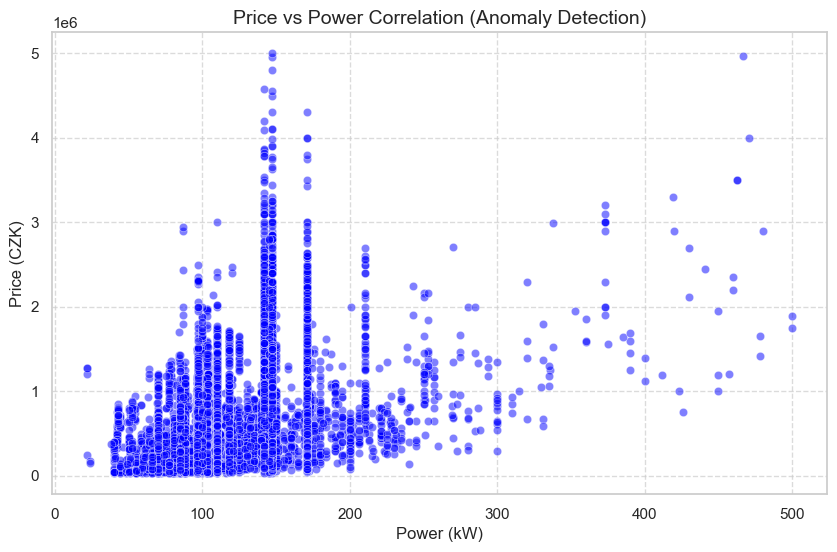

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (if your cleaned data is in a different file, change the name)
df = pd.read_csv('data/cars_ready.csv')

# If your dataframe is not named df, just change df to your variable name! 😉

print("--- 📊 Power Column Statistics ---")
display(df['power'].describe())

print("\n--- 🏎️ Top 5 cars with MAXIMUM power (looking for top outliers) ---")
display(df[[ 'brand', 'price', 'year', 'mileage', 'power']].sort_values(by='power', ascending=False).head(5))

print("\n--- 🐢 Top 5 cars with MINIMUM power (looking for zeros or bottom junk) ---")
display(df[[ 'brand', 'price', 'year', 'mileage', 'power']].sort_values(by='power').head(5))

# Plotting the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='power', y='price', alpha=0.5, color='blue')
plt.title('Price vs Power Correlation (Anomaly Detection)', fontsize=14)
plt.xlabel('Power (kW)', fontsize=12)
plt.ylabel('Price (CZK)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error

print("📥 1. Loading clean data...")
# Loading the already cured dataset! No extra power cleaning needed.
df = pd.read_csv('data/cars_ready.csv')

📥 1. Loading clean data...


In [14]:
print("🧠 2. Feature Engineering (Clusters, Age, Text Mining)...")
# Clustering
X_cluster = df[['year', 'mileage', 'power']].copy()
X_scaled = StandardScaler().fit_transform(X_cluster)
df['segment'] = KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(X_scaled).astype(str)

# Car Age
df['car_age'] = 2026 - df['year']

# Extracting gold from text!
df['details'] = df['details'].fillna("Unknown").astype(str)
details_lower = df['details'].str.lower()

df['is_4x4'] = details_lower.str.contains(r'4x4|awd|quattro|xdrive|4matic').astype(int)
df['is_automatic'] = details_lower.str.contains(r'automat|dsg|tiptronic|stronic').astype(int)
df['is_sport'] = details_lower.str.contains(r'rs|gti|m-packet|amg|sport|s-line').astype(int)
df['has_led'] = details_lower.str.contains(r'led|matrix|xenon').astype(int)

print("📉 3. Preparing for training...")
# Dropping text (we've already extracted everything useful from it)
X = df.drop(columns=['price', 'details']) 
y = df['price']

# Log-transforming the price! (Helps with skewed data)
y_log = np.log1p(y) 

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Categorical features handling
cat_features = ['brand', 'fuel', 'gearbox', 'segment'] 
for col in cat_features:
    X_train[col] = X_train[col].fillna("Unknown").astype(str)
    X_test[col] = X_test[col].fillna("Unknown").astype(str)

🧠 2. Feature Engineering (Clusters, Age, Text Mining)...
📉 3. Preparing for training...


In [15]:
print(f"🚀 4. Initializing CatBoost (on {len(X_train)} cars)...")
model = CatBoostRegressor(
    iterations=1500,    
    learning_rate=0.08, 
    depth=7,
    loss_function='RMSE',
    verbose=100,        
    random_seed=42
)

model.fit(
    X_train, y_train_log, 
    cat_features=cat_features,
    eval_set=(X_test, y_test_log),
    early_stopping_rounds=50
)
print("💾 Model saved in memory!")

🚀 4. Initializing CatBoost (on 15052 cars)...
0:	learn: 0.8517945	test: 0.8503984	best: 0.8503984 (0)	total: 64.5ms	remaining: 1m 36s
100:	learn: 0.2993967	test: 0.2917962	best: 0.2917962 (100)	total: 472ms	remaining: 6.53s
200:	learn: 0.2799442	test: 0.2816824	best: 0.2816824 (200)	total: 949ms	remaining: 6.13s
300:	learn: 0.2693427	test: 0.2775713	best: 0.2775713 (300)	total: 1.34s	remaining: 5.35s
400:	learn: 0.2625305	test: 0.2755444	best: 0.2755444 (400)	total: 1.77s	remaining: 4.85s
500:	learn: 0.2574100	test: 0.2742664	best: 0.2742640 (499)	total: 2.18s	remaining: 4.35s
600:	learn: 0.2525933	test: 0.2733911	best: 0.2732810 (571)	total: 2.6s	remaining: 3.89s
700:	learn: 0.2482650	test: 0.2726631	best: 0.2726151 (682)	total: 3s	remaining: 3.42s
800:	learn: 0.2447475	test: 0.2721982	best: 0.2721957 (798)	total: 3.38s	remaining: 2.95s
900:	learn: 0.2414117	test: 0.2717676	best: 0.2717010 (878)	total: 3.85s	remaining: 2.56s
Stopped by overfitting detector  (50 iterations wait)

bestT

In [16]:
print("📊 5. Calculating metrics...")
# Reverting log-prices back to real CZK
predictions_real = np.expm1(model.predict(X_test))
y_test_real = np.expm1(y_test_log)

r2 = r2_score(y_test_real, predictions_real)
mae = mean_absolute_error(y_test_real, predictions_real)
mape = mean_absolute_percentage_error(y_test_real, predictions_real)

print("\n" + "="*45)
print(f"🏆 FINAL SUPER-RESULT:")
print(f"📊 Accuracy (R2 Score): {r2:.4f}") 
print(f"💰 Average Error (MAE): {mae:,.0f} CZK")
print(f"🎯 Error Percentage (MAPE): {mape:.2%}")
print("="*45)

📊 5. Calculating metrics...

🏆 FINAL SUPER-RESULT:
📊 Accuracy (R2 Score): 0.8109
💰 Average Error (MAE): 107,044 CZK
🎯 Error Percentage (MAPE): 20.40%


🎨 Plotting graphs...


/var/folders/nf/_plpz1p57pv31n9md8s7b1s40000gn/T/ipykernel_22649/3446258981.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importances", y="Feature Id", data=feat_imp, palette="magma", ax=axes[1])


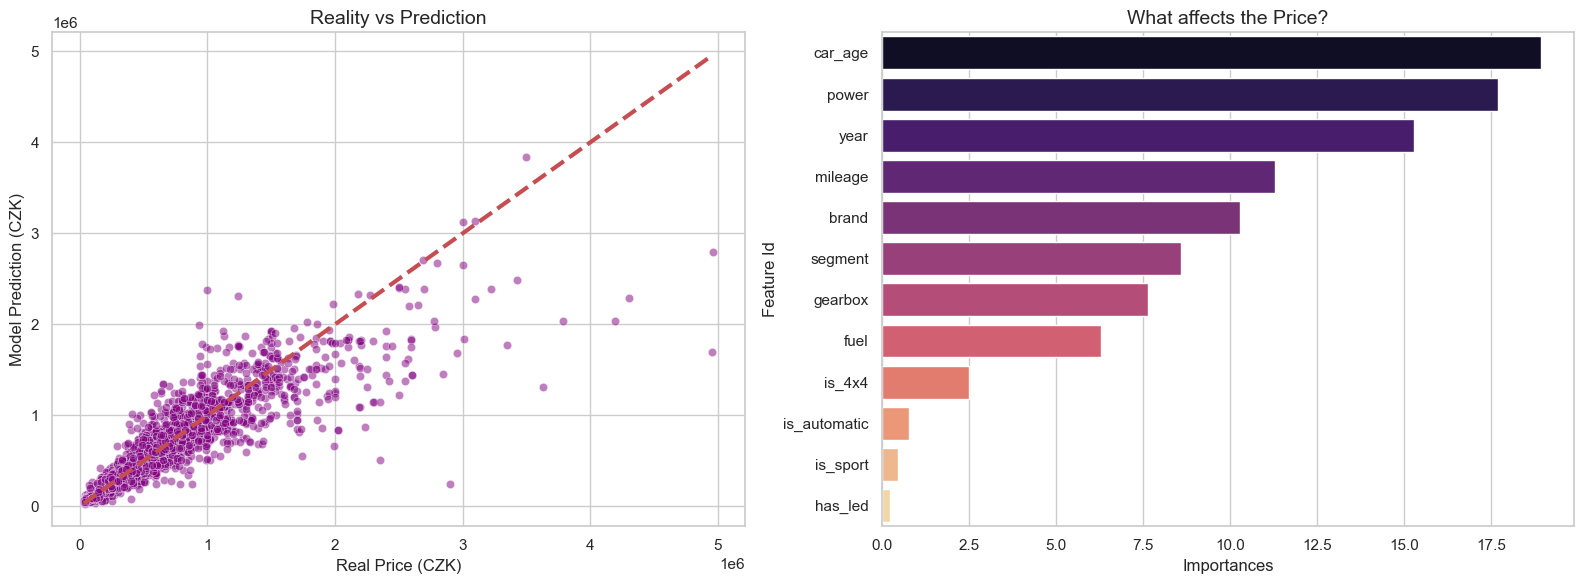

In [17]:
print("🎨 Plotting graphs...")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: Reality vs Prediction
sns.scatterplot(x=y_test_real, y=predictions_real, alpha=0.5, color='purple', ax=axes[0])
axes[0].plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'r--', lw=3)
axes[0].set_title('Reality vs Prediction', fontsize=14)
axes[0].set_xlabel('Real Price (CZK)')
axes[0].set_ylabel('Model Prediction (CZK)')

# Graph 2: Feature Importance
feat_imp = model.get_feature_importance(prettified=True).head(15)
sns.barplot(x="Importances", y="Feature Id", data=feat_imp, palette="magma", ax=axes[1])
axes[1].set_title('What affects the Price?', fontsize=14)

plt.tight_layout()
plt.show()

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# X - all features, y - our target (price)
X = df.drop(columns=['price', 'details'])
y = df['price']

X_encoded = pd.get_dummies(X, drop_first=True)

In [19]:
X_trainlin, X_testlin, y_trainlin, y_testlin = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [20]:
# Finding numeric columns (ignoring boolean/uint8 columns created by get_dummies)
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Creating a scaler object
scaler = StandardScaler()

# Training (fitting) the scaler ONLY on X_train and immediately applying (transforming)
X_trainlin[num_cols] = scaler.fit_transform(X_trainlin[num_cols])

# For X_test ONLY apply (transform), so the model doesn't peek into the future!
X_testlin[num_cols] = scaler.transform(X_testlin[num_cols])

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [22]:
#X_trainlin, X_testlin, y_trainlin, y_testlin

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
}

results = []

for name, model in models.items():
    print(f"Training {name}...")
    
    # Training
    model.fit(X_trainlin, y_trainlin) 
    
    # Prediction    
    y_pred = model.predict(X_testlin)
    
    # Collecting metrics
    mae = mean_absolute_error(y_testlin, y_pred)
    r2 = r2_score(y_testlin, y_pred)
    mape = mean_absolute_percentage_error(y_testlin, y_pred)
    
    results.append({"Model": name, "MAE": mae, "R2 Score": r2, "MAPE": mape})

# Transforming results into a DataFrame for convenience
results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
display(results_df)

Training Linear Regression...
Training Random Forest...


,Model,MAE,R2 Score,MAPE
1,Random Forest,115849.896226,0.788438,0.243726
0,Linear Regression,177498.598242,0.667003,0.570276


In [23]:
# Проверим, какие переменные вообще сейчас есть в памяти
# Если X_encoded существует, мы увидим его размер
try:
    print(f"Общий размер X_encoded: {X_encoded.shape}")
    print(f"Количество уникальных колонок: {X_encoded.shape[1]}")
    # Посмотрим на первые 5 названий колонок
    print("Примеры колонок:", X_encoded.columns[:5].tolist())
except NameError:
    print("❌ Переменная X_encoded не найдена! Нужно запустить ячейку с pd.get_dummies")

Общий размер X_encoded: (18816, 39)
Количество уникальных колонок: 39
Примеры колонок: ['year', 'mileage', 'power', 'car_age', 'is_4x4']
